In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Tuple, Literal, Dict, List

import numpy as np
import matplotlib.pyplot as plt
import optax
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.random import PRNGKey
from jax.flatten_util import ravel_pytree
import gymnax


In [ ]:
# ---------------------------
# Step 0: Shared config
# ---------------------------

@dataclass
class Config:
    seed: int = 42
    env_name: str = "Pendulum-v1"

    # MDP / return
    gamma: float = 0.99 # Discount factor
    horizon: int = 200  # overridden by env_params.max_steps_in_episode

    # Discrete action set
    num_actions: int = 3
    action_max: float = 2.0
    # action_list is built at runtime as linspace(-action_max,action_max,num_actions)

    # Neural policy (MLP)
    # Policy network settings
    hidden_sizes: Tuple[int, int] = (64, 64)
    init_scale: float = 1e-2

    # CEM hyperparams
    cem_iters: int = 200
    cem_init_std: float = 0.5
    cem_popsize: int = 64
    cem_elite_frac: float = 0.1
    cem_fitness_episodes: int = 5
    cem_min_std: float = 0.05
    cem_alpha: float = 0.7  # smoothing (higher = slower updates)

    # ---- ES hyperparams ----
    es_iters: int = 200
    es_popsize: int = 64
    es_sigma: float = 0.2
    es_lr: float = 0.01
    es_fitness_episodes: int = 5

    # Logging
    eval_every: int = 5

cfg = Config()
cfg


Config(seed=42, env_name='Pendulum-v1', gamma=0.99, horizon=200, num_actions=3, action_max=2.0, hidden_sizes=(64, 64), init_scale=0.01, cem_iters=200, cem_init_std=0.5, cem_popsize=64, cem_elite_frac=0.1, cem_fitness_episodes=5, cem_min_std=0.05, cem_alpha=0.7, es_iters=200, es_popsize=64, es_sigma=0.2, es_lr=0.01, es_fitness_episodes=5, eval_every=5)

In [ ]:
# ---------------------------
# Step 2: Neural policy πθ
# ---------------------------

def initialize_mlp(layer_sizes: Tuple[int, ...], key: PRNGKey, scale: float = 1e-1):
    """Return a list of (W,b) tuples."""
    params = []
    keys = jr.split(key, 2 * (len(layer_sizes) - 1))
    k = 0
    for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = jr.normal(keys[k], (in_dim, out_dim)) * scale
        b = jnp.zeros((out_dim,))
        params.append((W, b))
        k += 1
    return params


In [19]:
def mlp_forward(params, x: jnp.ndarray) -> jnp.ndarray:
    """Simple MLP forward pass."""
    for (W, b) in params[:-1]:
        x = jnp.dot(x, W) + b
        x = jax.nn.relu(x)
    W, b = params[-1]
    return jnp.dot(x, W) + b


In [20]:
def policy_logits(params, obs: jnp.ndarray) -> jnp.ndarray:
    """Logits over a small discrete torque set."""
    return mlp_forward(params, obs).squeeze()  # (num_actions,)

def action_list(cfg: Config) -> jnp.ndarray:
    return jnp.linspace(-cfg.action_max, cfg.action_max, cfg.num_actions).astype(jnp.float32)

def policy_action_deterministic(params, obs: jnp.ndarray, cfg: Config) -> jnp.ndarray:
    """Deterministic action for evaluation/fitness: argmax over logits."""
    logits = policy_logits(params, obs)
    a_idx = jnp.argmax(logits)
    u = action_list(cfg)[a_idx]
    return jnp.array([u], dtype=jnp.float32)


In [ ]:
# ---------------------------
# Step 3: Rollout -> Return (Fitness)  (deterministic policy, discrete actions)
# ---------------------------

def rollout_return(env, env_params, params, key: PRNGKey, cfg: Config) -> jnp.ndarray:
    """One episode rollout, returns discounted return."""
    key, k_reset = jr.split(key, 2)
    obs, state = env.reset(k_reset, env_params)

    def step_fn(carry, _t):
        key, obs, state, G, gpow, alive = carry
        key, k_step = jr.split(key, 2)

        action = policy_action_deterministic(params, obs, cfg)
        next_obs, next_state, reward, done, _info = env.step(k_step, state, action, env_params)

        # Stop accumulating after termination (Pendulum doesn't usually terminate early, but keep it consistent)
        alive_next = alive * (1.0 - done)
        G = G + gpow * reward * alive_next
        gpow = gpow * cfg.gamma

        return (key, next_obs, next_state, G, gpow, alive_next), None

    horizon = int(env_params.max_steps_in_episode) if hasattr(env_params, "max_steps_in_episode") else int(cfg.horizon)
    init = (key, obs, state, jnp.array(0.0), jnp.array(1.0), jnp.array(1.0))
    (key, obs, state, G, gpow, alive), _ = jax.lax.scan(step_fn, init, xs=None, length=horizon)
    return G


def fitness(env, env_params, params, key: PRNGKey, cfg: Config, episodes: int) -> jnp.ndarray:
    """Average return over `episodes` rollouts."""
    keys = jr.split(key, episodes)
    returns = jax.vmap(lambda k: rollout_return(env, env_params, params, k, cfg))(keys)
    return jnp.mean(returns)


In [22]:
# JIT compile fitness over a batch of candidates (big speed-up)
def make_population_fitness_fn(env, env_params, unravel, cfg: Config, episodes: int):
    @jax.jit
    def pop_fit(thetas: jnp.ndarray, key: PRNGKey) -> jnp.ndarray:
        keys = jr.split(key, thetas.shape[0])

        def one(theta, k):
            p = unravel(theta)
            return fitness(env, env_params, p, k, cfg, episodes)

        return jax.vmap(one)(thetas, keys)

    return pop_fit


In [23]:
# ---------------------------
# Step 5: CEM optimizer
# ---------------------------

def train_cem(env, env_params, theta0: jnp.ndarray, unravel, cfg: Config) -> Dict[str, List[float]]:
    dim = theta0.shape[0]
    elite_n = max(1, int(cfg.cem_popsize * cfg.cem_elite_frac))

    key = jr.PRNGKey(cfg.seed)

    mu = theta0
    sigma = jnp.ones((dim,)) * cfg.cem_init_std  # diagonal gaussian

    pop_fit = make_population_fitness_fn(env, env_params, unravel, cfg, cfg.cem_fitness_episodes)

    hist = {"iter": [], "best": [], "elite_mean": [], "mu_eval": [], "sigma_mean": []}

    for it in range(1, cfg.cem_iters + 1):
        key, k_pop, k_mu = jr.split(key, 3)

        # sample population
        eps = jr.normal(k_pop, (cfg.cem_popsize, dim))
        thetas = mu[None, :] + eps * sigma[None, :]

        # evaluate fitness
        fits = pop_fit(thetas, k_pop)

        # pick elites
        idx = jnp.argsort(fits)[-elite_n:]
        elites = thetas[idx]
        elite_fits = fits[idx]

        # update distribution
        new_mu = jnp.mean(elites, axis=0)
        new_sigma = jnp.std(elites, axis=0)
        new_sigma = jnp.maximum(new_sigma, cfg.cem_min_std)

        # smoothing
        mu = cfg.cem_alpha * mu + (1.0 - cfg.cem_alpha) * new_mu
        sigma = cfg.cem_alpha * sigma + (1.0 - cfg.cem_alpha) * new_sigma

        # evaluate current mean policy
        mu_eval = float(fitness(env, env_params, unravel(mu), k_mu, cfg, cfg.cem_fitness_episodes))

        # log
        hist["iter"].append(it)
        hist["best"].append(float(jnp.max(fits)))
        hist["elite_mean"].append(float(jnp.mean(elite_fits)))
        hist["mu_eval"].append(mu_eval)
        hist["sigma_mean"].append(float(jnp.mean(sigma)))

        if it % cfg.eval_every == 0 or it == 1 or it == cfg.cem_iters:
            print(
                f"[CEM] iter={it:03d}  best(pop)={hist['best'][-1]:8.1f}  "
                f"elite_mean={hist['elite_mean'][-1]:8.1f}  mu_eval={mu_eval:8.1f}  "
                f"mean_sigma={hist['sigma_mean'][-1]:.3f}"
            )

    return hist


In [ ]:
# ---------------------------
# Step 6: ES optimizer
# ---------------------------

def train_es(env, env_params, theta0: jnp.ndarray, unravel, cfg: Config) -> Dict[str, List[float]]:
    """Very simple antithetic ES update."""
    dim = theta0.shape[0]
    key = jr.PRNGKey(cfg.seed)

    theta = theta0
    pop_fit = make_population_fitness_fn(env, env_params, unravel, cfg, 1)

    hist = {"iter": [], "theta_eval": []}

    for it in range(1, cfg.es_iters + 1):
        key, k_eps, k_eval = jr.split(key, 3)

        # sample noise
        eps = jr.normal(k_eps, (cfg.es_popsize, dim))

        thetas_plus = theta[None, :] + cfg.es_sigma * eps
        thetas_minus = theta[None, :] - cfg.es_sigma * eps

        f_plus = pop_fit(thetas_plus, k_eps)
        f_minus = pop_fit(thetas_minus, k_eps)

        # ES "gradient estimate"
        weights = (f_plus - f_minus)[:, None]  # (N,1)
        grad_est = jnp.mean(weights * eps, axis=0) / (2.0 * cfg.es_sigma)

        # update
        theta = theta + cfg.es_lr * grad_est

        # evaluate
        theta_eval = float(fitness(env, env_params, unravel(theta), k_eval, cfg, cfg.es_fitness_episodes))
        hist["iter"].append(it)
        hist["theta_eval"].append(theta_eval)

        if it % cfg.eval_every == 0 or it == 1 or it == cfg.es_iters:
            print(f"[ES ] iter={it:03d}  theta_eval={theta_eval:8.1f}")

    return hist


Using horizon=200 steps per episode
Initial deterministic fitness (avg return): -651.573486328125
[CEM] iter=001  best(pop)=  -370.3  elite_mean=  -429.5  mu_eval=  -640.4  mean_sigma=0.481
[CEM] iter=005  best(pop)=  -395.0  elite_mean=  -420.5  mu_eval=  -573.7  mean_sigma=0.409
[CEM] iter=010  best(pop)=  -294.5  elite_mean=  -404.4  mu_eval=  -546.3  mean_sigma=0.335
[CEM] iter=015  best(pop)=  -380.3  elite_mean=  -415.3  mu_eval=  -409.8  mean_sigma=0.274
[CEM] iter=020  best(pop)=  -366.6  elite_mean=  -421.8  mu_eval=  -619.0  mean_sigma=0.224
[CEM] iter=025  best(pop)=  -384.1  elite_mean=  -410.8  mu_eval=  -441.3  mean_sigma=0.183
[CEM] iter=030  best(pop)=  -364.9  elite_mean=  -401.2  mu_eval=  -503.6  mean_sigma=0.151
[CEM] iter=035  best(pop)=  -319.3  elite_mean=  -372.3  mu_eval=  -522.1  mean_sigma=0.125
[CEM] iter=040  best(pop)=  -369.1  elite_mean=  -398.7  mu_eval=  -640.1  mean_sigma=0.105
[CEM] iter=045  best(pop)=  -400.1  elite_mean=  -416.4  mu_eval=  -460.6 

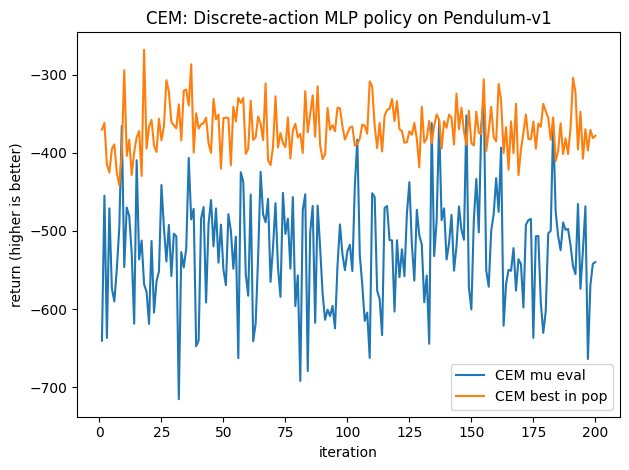


Done.


In [ ]:
# ---------------------------
# Step 7: Run + Plot
# ---------------------------

import matplotlib.pyplot as plt

# Step 1: Environment / MDP
env, env_params = gymnax.make(cfg.env_name)

# Override horizon from env params if present
horizon = int(env_params.max_steps_in_episode) if hasattr(env_params, "max_steps_in_episode") else int(cfg.horizon)
print(f"Using horizon={horizon} steps per episode")

# Get obs dimension
key = jr.PRNGKey(cfg.seed)
key, k_reset = jr.split(key, 2)
obs, _state = env.reset(k_reset, env_params)
obs_dim = int(obs.shape[0])

# Step 2: Initialize policy params (MLP) -> logits over discrete actions
key, k_init = jr.split(key, 2)
layer_sizes = (obs_dim, *cfg.hidden_sizes, cfg.num_actions)
params0 = initialize_mlp(layer_sizes, key=k_init, scale=cfg.init_scale)

# Flatten params for evolution optimizers
theta0, unravel = ravel_pytree(params0)

print("Initial deterministic fitness (avg return):",
      float(fitness(env, env_params, params0, key, cfg, episodes=cfg.cem_fitness_episodes)))

# ---- Run CEM ----
hist_cem = train_cem(env, env_params, theta0, unravel, cfg)

# Plot CEM curve
plt.figure()
plt.plot(hist_cem["iter"], hist_cem["mu_eval"], label="CEM mu eval")
plt.plot(hist_cem["iter"], hist_cem["best"], label="CEM best in pop")
plt.xlabel("iteration")
plt.ylabel("return (higher is better)")
plt.title("CEM: Discrete-action MLP policy on Pendulum-v1")
plt.legend()
plt.tight_layout()
plt.show()

print("\nDone.")


[ES ] iter=001  theta_eval=  -631.4
[ES ] iter=005  theta_eval=  -573.7
[ES ] iter=010  theta_eval=  -546.3
[ES ] iter=015  theta_eval=  -408.9
[ES ] iter=020  theta_eval=  -614.6
[ES ] iter=025  theta_eval=  -441.3
[ES ] iter=030  theta_eval=  -488.1
[ES ] iter=035  theta_eval=  -474.0
[ES ] iter=040  theta_eval=  -468.7
[ES ] iter=045  theta_eval=  -439.4
[ES ] iter=050  theta_eval=  -508.2
[ES ] iter=055  theta_eval=  -417.5
[ES ] iter=060  theta_eval=  -460.1
[ES ] iter=065  theta_eval=  -388.4
[ES ] iter=070  theta_eval=  -485.7
[ES ] iter=075  theta_eval=  -396.8
[ES ] iter=080  theta_eval=  -654.1
[ES ] iter=085  theta_eval=  -485.2
[ES ] iter=090  theta_eval=  -484.8
[ES ] iter=095  theta_eval=  -567.7
[ES ] iter=100  theta_eval=  -493.1
[ES ] iter=105  theta_eval=  -527.4
[ES ] iter=110  theta_eval=  -440.6
[ES ] iter=115  theta_eval=  -524.3
[ES ] iter=120  theta_eval=  -489.6
[ES ] iter=125  theta_eval=  -405.0
[ES ] iter=130  theta_eval=  -482.5
[ES ] iter=135  theta_eval= 

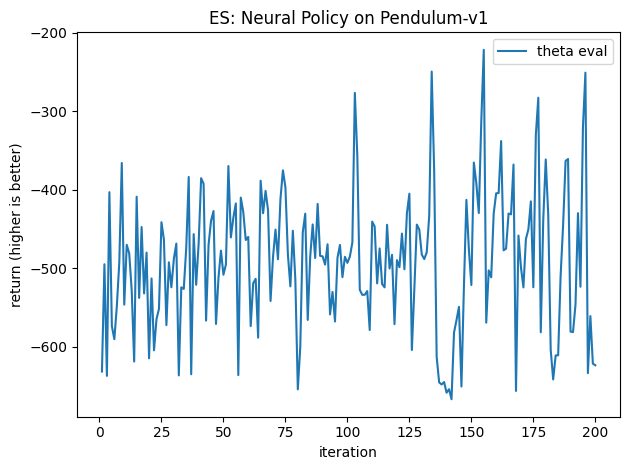

In [31]:
hist = train_es(env, env_params, theta0, unravel, cfg)

it = np.array(hist["iter"])
plt.figure()
plt.plot(it, hist["theta_eval"], label="theta eval")
plt.xlabel("iteration")
plt.ylabel("return (higher is better)")
plt.title("ES: Neural Policy on Pendulum-v1")

plt.legend()
plt.tight_layout()
plt.show()